## Fetch and view three atlases of your choice from nilearn.datasets

First, I chose the AAL3 atlas because it is the atlas used in my thesis research. AAL3 is like your standard, traditional city map. It divides the brain based on strict, physical landmarks.

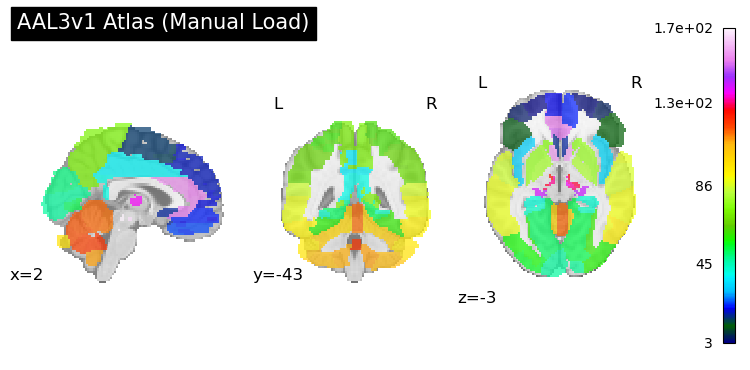

In [ ]:
from nilearn import datasets
import os
from nilearn.maskers import NiftiLabelsMasker
from nilearn.plotting import view_img
from nilearn import datasets
from nilearn import plotting


atlas_dir = "/mnt/c/HHHHHOMEWORK/AAL_ATLAS/AAL3"


aal_maps_path = os.path.join(atlas_dir, "AAL3v1.nii")
aal_labels_path = os.path.join(atlas_dir, "AAL3v1.nii.txt")
labels = []

with open(aal_labels_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            # 取第二個部分作為腦區名稱
            roi_name = parts[1]
            labels.append(roi_name)


AAL_atlas = {
    'maps': aal_maps_path,
    'labels': labels
}



plotting.plot_roi(
    AAL_atlas['maps'],
    title="AAL3v1 Atlas (Manual Load)",
    display_mode='ortho',
    draw_cross=False,
    annotate=True
)


Second is the Harvard-Oxford atlas. Reather than a one-fits-all boundary. Harvard–Oxford atlas is more like segmentation. Its regions are defined based on probabilistic tissue and anatomical boundaries.


Finally, Yeo 2011 atlas is completely different. Also used in my thesis, It completely ignores physical anatomy and instead separated purely at functional network.



[fetch_atlas_harvard_oxford] Dataset found in /home/william/nilearn_data/fsl

[fetch_atlas_yeo_2011] Dataset found in /home/william/nilearn_data/yeo_2011

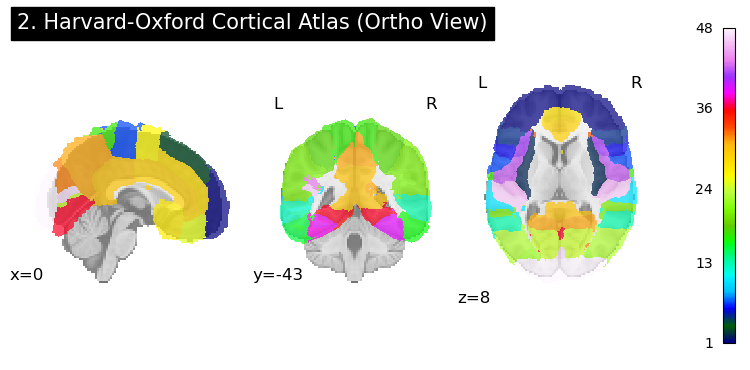

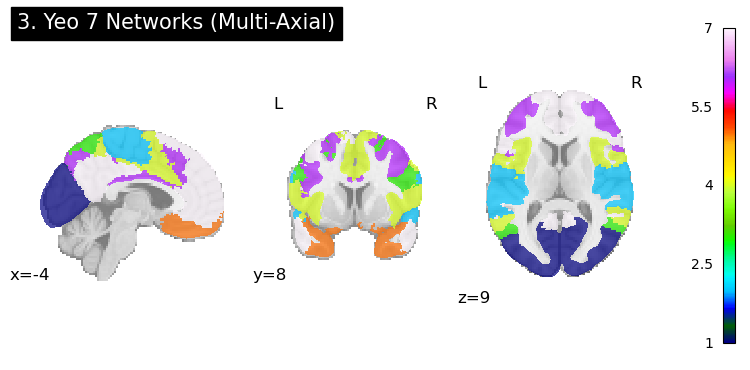

In [ ]:
import matplotlib.pyplot as plt
from nilearn import datasets
from nilearn import plotting

# 2. Harvard-Oxford Cortical Atlas


ho_atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr0-1mm')



plotting.plot_roi(
    ho_atlas.maps,
    title="2. Harvard-Oxford Cortical Atlas (Ortho View)",
    display_mode='ortho',
    draw_cross=False,
    annotate=True
)


# 3. Yeo 2011 Functional Networks (7 Networks)
yeo_atlas = datasets.fetch_atlas_yeo_2011(n_networks=7, thickness='thick')


yeo_7_networks = yeo_atlas.maps


plotting.plot_roi(
    yeo_atlas.maps,
    title="3. Yeo 7 Networks (Multi-Axial)",
    display_mode='ortho',
    draw_cross=False,
    annotate=True
)

plt.show()


# Compare and discuss

Compare the atlas parcellations and discuss your observations below. What might be some reasons that parcellation could affect your functional connectivity results?

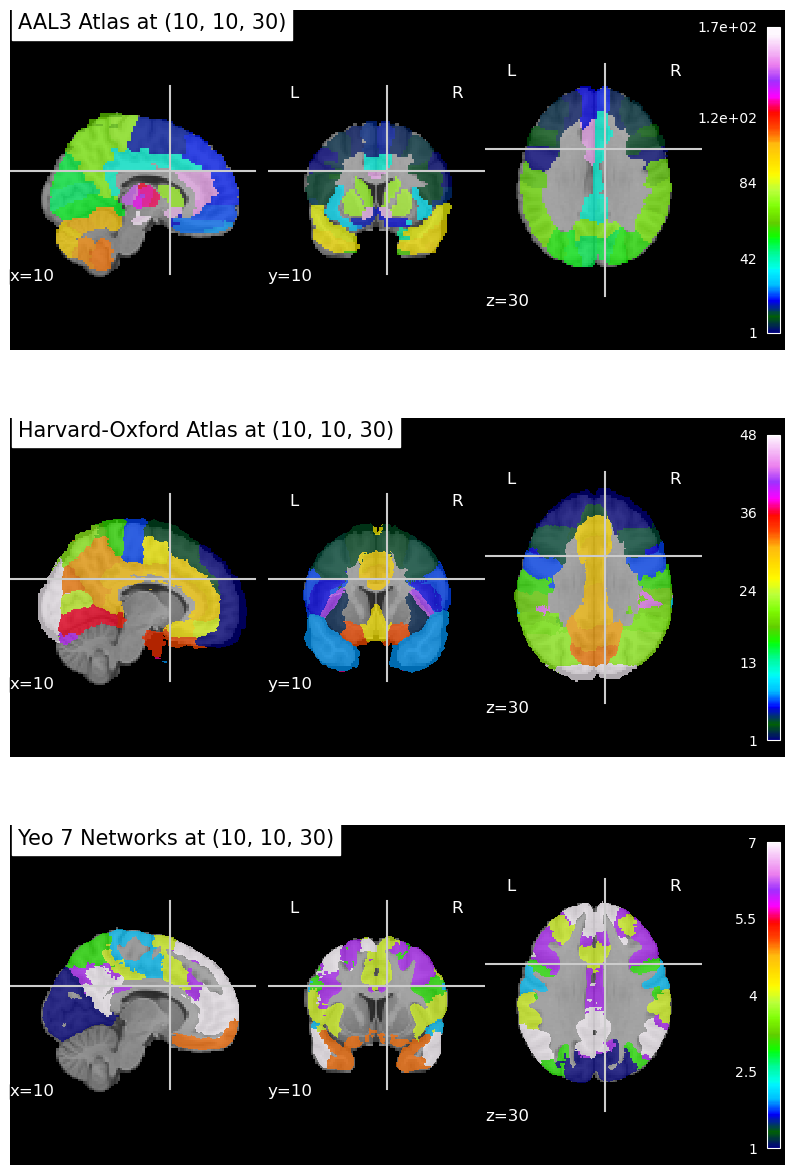

In [ ]:
import matplotlib.pyplot as plt
from nilearn import plotting


target_coords = (10, 10, 30)
target_coords2 = [10, 10, 30]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))

# --- AAL3 ---
plotting.plot_roi(
    AAL_atlas['maps'],
    title=f"AAL3 Atlas at {target_coords}",
    axes=axes[0],
    colorbar=True,
    black_bg=True,
    cut_coords=target_coords2,
    display_mode='ortho'
)

# --- Harvard-Oxford ---
plotting.plot_roi(
    ho_atlas.maps,
    title=f"Harvard-Oxford Atlas at {target_coords}",
    axes=axes[1],
    colorbar=True,
    black_bg=True,
    cut_coords=target_coords2,
    display_mode='ortho'
)

# --- Yeo 7 Networks ---
plotting.plot_roi(
    yeo_atlas.maps,
    title=f"Yeo 7 Networks at {target_coords}",
    axes=axes[2],
    display_mode='ortho',
    colorbar=True,
    black_bg=True,
    cut_coords=target_coords2,
)




# 顯示圖片
plt.show()

In [ ]:
import numpy as np
from nilearn import datasets, image

target_coords = (10, 10, 30)

import numpy as np
from nilearn import image


path_string = AAL_atlas['maps']
img_object = image.load_img(path_string)


voxel_coords = image.coord_transform(
    target_coords[0], target_coords[1], target_coords[2],
    np.linalg.inv(img_object.affine))

x, y, z = np.round(voxel_coords).astype(int)

data = img_object.get_fdata()
label_index = int(data[x, y, z])

region_name = AAL_atlas['labels'][label_index]
print(f"MNI 座標 (10, 10, 30)")
print(f"對應的AALv3名稱為: {region_name}")


#///////////////////////////////////////////////////////////////////////////
voxel_coords = image.coord_transform(
    target_coords[0], target_coords[1], target_coords[2],
    np.linalg.inv(ho_atlas.maps.affine)
)

x, y, z = np.round(voxel_coords).astype(int)
data = ho_atlas.maps.get_fdata()
label_index = int(data[x, y, z])
region_name = ho_atlas.labels[label_index]

print(f"對應的ho_atlas名稱為: {region_name}")

#///////////////////////////////////////////////////////////////////////////
voxel_coords = image.coord_transform(
    target_coords[0], target_coords[1], target_coords[2],
    np.linalg.inv(img_object.affine)
)

# 將計算出的浮點數座標四捨五入成整數索引
x, y, z = np.round(voxel_coords).astype(int)

# 4. 提取數據並查詢該位置的標籤數值
data = img_object.get_fdata()
label_index = int(data[x, y, z])

# 查詢對應的網路名稱
region_name = yeo_atlas.labels[label_index]

print(f"對應的Yeo_atlas名稱為: {region_name}")